In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from tqdm import trange

In [2]:
def check(sigma, alpha, mu, yt):
    eps = 1.5
    cov = sigma ** 2
    P_fn = lambda t: np.exp(-2*alpha*t) * cov / eps + (1 - np.exp(-2*alpha*t)) / 2 / alpha
    q_fn = lambda t: np.exp(-alpha*t) * mu
    
    dt = 0.001
    N = 1000
    t = 0
    M = int(1e6)
    zt = yt * np.ones(shape=[M])

    t = 0
    for i in trange(N):
        update = - 1/P_fn(T - t) * (zt - q_fn(T-t)) + alpha * zt
        zt = zt + update * dt + np.sqrt(eps*dt) * np.random.normal(size=zt.shape)
        t = t + dt
        
        
    x = np.linspace(-10, 10, 10001)
    A = 1/np.sqrt(2*np.pi*sigma**2) * np.exp(-1/2/sigma**2*(x - mu) ** 2)
    B = np.sqrt(alpha/(eps * np.pi * (1-np.exp(-2*alpha*T)))) * np.exp(-alpha/eps/(1-np.exp(-2*alpha*T)) * (yt - np.exp(-alpha*T)*x) ** 2)
    C = 1/np.sqrt(np.pi * (2*np.exp(-2*alpha*T)*sigma**2 + eps*(1-np.exp(-2*alpha*T))/alpha))
    D = np.exp(-1/(2*np.exp(-2*alpha*T)*sigma**2 + eps/alpha*(1-np.exp(-2*alpha*T))) * (yt - np.exp(-alpha*T)*mu) ** 2)
    f = A * B / C / D
    
    return zt, x, f

In [3]:
T = 1
alpha = 2.0
mu = 0
sigma = 1


yt = -10
zt1, x1, f1 = check(sigma=sigma, alpha=alpha, mu=mu, yt=yt)
yt = -6
zt2, x2, f2 = check(sigma=sigma, alpha=alpha, mu=mu, yt=yt)
yt = -3
zt3, x3, f3 = check(sigma=sigma, alpha=alpha, mu=mu, yt=yt)
yt = 4
zt4, x4, f4 = check(sigma=sigma, alpha=alpha, mu=mu, yt=yt)
yt = 8
zt5, x5, f5 = check(sigma=sigma, alpha=alpha, mu=mu, yt=yt)

100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:30<00:00, 32.29it/s]


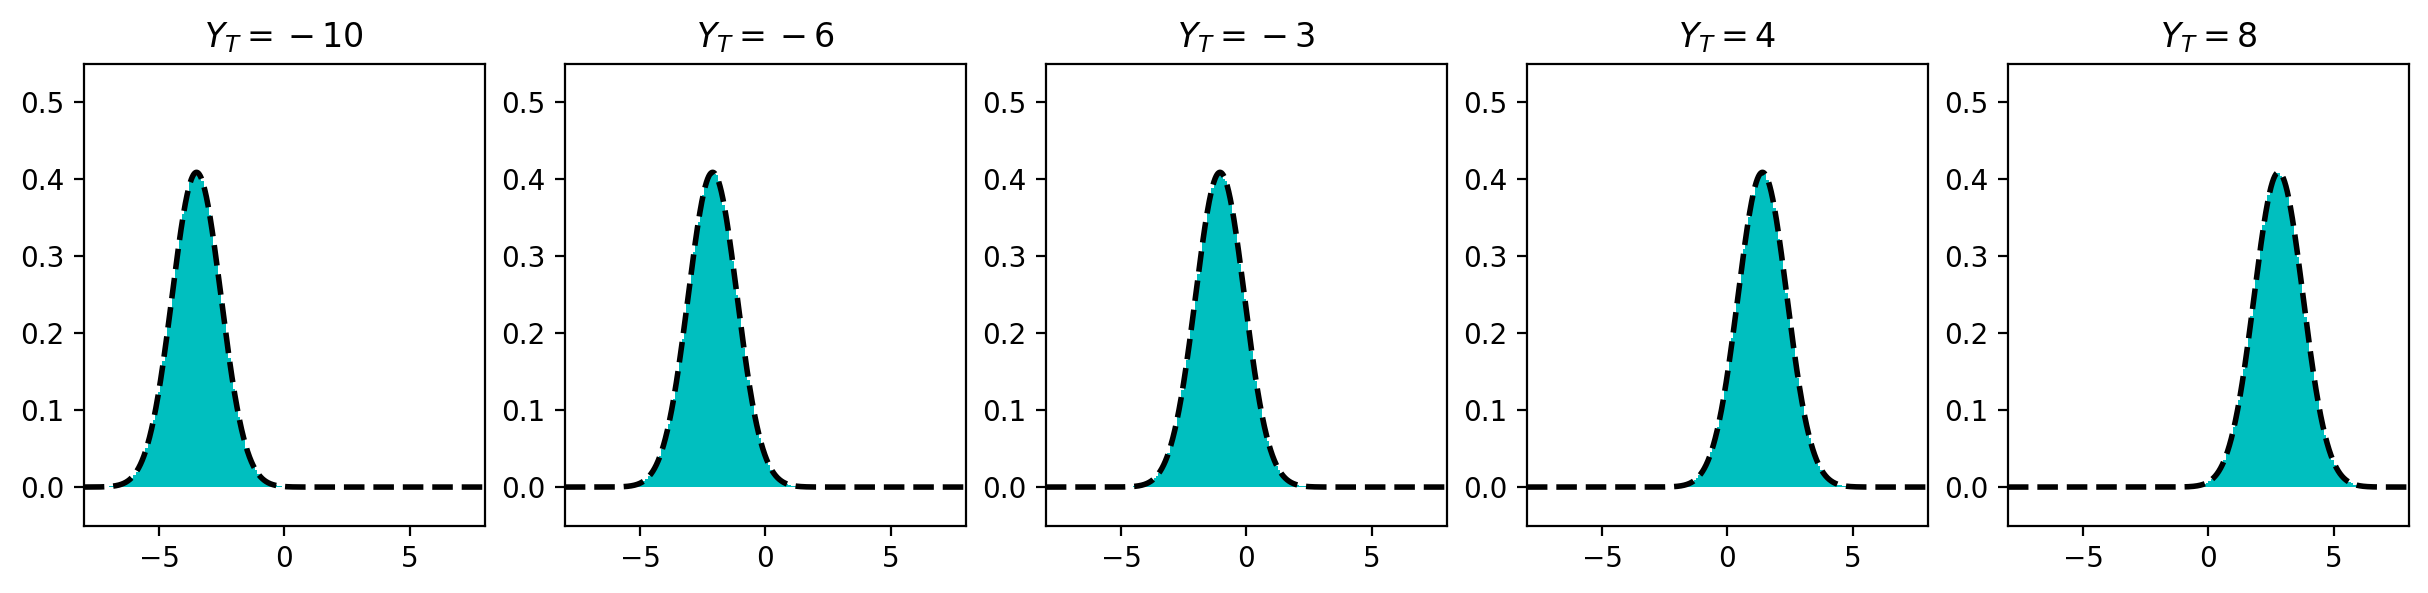

In [4]:
x = x1
fs = [f1, f2 ,f3, f4, f5]
yts = [-10, -6, -3, 4, 8]
zts = [zt1, zt2, zt3, zt4, zt5]
fig, axes = plt.subplots(1, 5, figsize=[15, 3], dpi=200)
for i in range(len(zts)):
    axes[i].hist(zts[i], bins=100, density=True, color="c")
    axes[i].plot(x, fs[i], "k--", label="The exact posterior", linewidth=2)
   
    # axes[i].set_title("$Y_T={}$".format(str(yts[i])))
    axes[i].set_title("$Y_T={}$".format(str(yts[i])))
    axes[i].set_ylim([-0.05, 0.55])
    axes[i].set_xlim([-8, 8])
fig.savefig("./figs/analytic.png")
plt.show()